# BT5153 Group Prject Codes

# Topic: Toxic Comment Detection

In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [ ]:
# link to Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import packages
import os
import re
import json
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
from datasets import Dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [ ]:
# import datasets
# Update these paths if your files are stored elsewhere.

TOXIC_TRAIN_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv"
UNINTENDED_BIAS_TRAIN_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-unintended-bias-train.csv"
VALIDATION_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/validation.csv"
TEST_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/test.csv"

# Optional: if you also have test labels later
TEST_LABELS_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/test_labels.csv"

# Recommended Pipeline
---
## Module 0: Problem Framing
### Task: For each input comment, the model should output:
- a toxicity probability between 0 and 1.
- based on the threshold, a predicted toxicity label.

### Core project setting:
- **Train**: English-only data
- **Val/Test**: multilingal data
- **Goal**: evaluate **zero-shot cross-lingual generalization**

### Research questions the final report should answer:
1. Can a model trained only on English generalize to other languages?
2. How large is the performance gap across different model families?
3. What threshold design is most suitable for a moderation setting?
4. Which languages are the hardest, and why?
5. Are more complex models actually worth the extra cost?
6. Why to incorporate each model? Why baseline? Why each selected model is **supposed** to be stronger?
7. Compare multiple threshold design (e.g., no tuning / default 0.5, global recall-constrained threshold, language-specific recall-constrained threshold) and compare performance, recall, false-positive burdens, etc.
8. **If feasible**: per-language robustness analysis
---

## Module 1: Data Loading and sanity check

### What to load:
**Training inputs**:
- "jigsaw-toxic-comment-train.csv"
- "jigsaw-unintended-bias-train.csv"
- "jigsaw-toxic-comment-train-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**
- "jigsaw-unintended-bias-train-processed-seqlen128.csv"  **NO NEED cuz only for BERT!!!**

**Validation inputs**:
- "validation.csv"
- "validation-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**

**Test inputs**:
- "test.csv"
- "test-processed-seqlen128.csv" **NO NEED cuz only for BERT!!!**
- "test-labels.csv"

### What to check:
For each file, check:
1. shape
2. column names
3. data types
4. missing values
5. toxic class proportion
6. language distribution
7. whether the training data is truly English-only
8. which languages appear in validation and test
---

## Module 2. Data Preparation

### 2.1 Training Set Construction

### 2.2 Text Cleaning
Recommended:
- Remove empty/null comments
- Strip whitespace
- Remove duplicates

Avoid:
- Stemming
- Heavy punctuation removal
- Stopword removal

### 2.3 Sampling Strategy
- Stage A: small subset for prototyping
- Stage B: full dataset for final training

---
## Module 3. Exploratory Data Analysis (EDA)

### Tasks
- Class imbalance analysis
- Comment length distribution
- Language distribution (validation)
- Toxic ratio per language
- Train vs validation/test domain gap

### Potential Insights
- Language imbalance affects stability
- Toxic comments may differ in length/style
- Cross-lingual gap reflects both language and domain shift
---
## Module 4. Modeling

### 4.1 Baseline 1: TF-IDF + Logistic Regression
- `TfidfVectorizer` (1–2 grams)
- `LogisticRegression` (optional class_weight="balanced")

**Purpose**
- Fast, interpretable benchmark
- Captures surface-level patterns

---

### 4.2 Baseline 2: Neural Models (Choose 1–2)
- BiLSTM (sequence modeling)
- CNN (local pattern extraction)

**Recommendation**
- Do not over-invest in all variants
- Focus on representative models

---

### 4.3 Core Model 1: mBERT
- Fine-tune on English data
- Evaluate zero-shot multilingual performance

---

### 4.4 Core Model 2: XLM-R
- Stronger multilingual transformer
- Likely best-performing model

**Key Analysis**
- Compare with mBERT
- Analyze performance differences across languages

---

## Module 5. Threshold Optimization

### 5.1 Define Recall Floor
- Example:
  - Recall ≥ 0.80 or 0.85

### 5.2 Threshold Strategies

#### Global Threshold
- One threshold for all languages
- Pros: simple, realistic, consistent

#### Language-Specific Threshold
- Separate threshold per language
- Pros: better performance
- Cons: complex, unstable, requires language info

### Goal
- Maximize F1 under recall constraint

---

## Module 6. Evaluation

### Metrics

#### Probability-level
- ROC-AUC (overall)
- ROC-AUC (per language)

#### Threshold-level
- Precision
- Recall
- F1

#### Optional
- PR-AUC
- FPR / FNR

---

### Required Breakdowns
- By model
- By language
- By threshold strategy

---

### Robustness / Fairness Analysis
- Best vs worst language performance
- Recall variance across languages
- Performance drop (English → non-English)

---

## Module 7. Error Analysis and Interpretation

### Tasks
- Analyze false positives / false negatives
- Identify hardest languages
- Detect common failure patterns

### Traditional Model Interpretation
- Top positive/negative tokens (Logistic Regression)

### Transformer Interpretation
- Case studies
- Compare predictions across models

---

## Final Project Storyline

1. Build baseline (TF-IDF + Logistic Regression)
2. Add neural baseline (BiLSTM / CNN)
3. Introduce transformers (mBERT, XLM-R)
4. Evaluate cross-lingual performance
5. Optimize threshold (recall-constrained)
6. Compare global vs language-specific thresholds
7. Conduct error analysis and deployment discussion

# Module 1: Data loading and processing

In [ ]:
# Basic Utility Functions
def check_file_exists(path: str) -> None:
    """Raise an error if the file does not exist."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")


def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def standardize_text_column(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Standardize the text column name to 'comment_text'.

    Some datasets use 'content' instead of 'comment_text'.
    This function renames 'content' to 'comment_text' if needed.
    """
    df = df.copy()

    if "comment_text" in df.columns:
        return df

    if "content" in df.columns:
        df = df.rename(columns={"content": "comment_text"})
        return df

    raise ValueError(
        f"{dataset_name} does not contain 'comment_text' or 'content' column."
    )


def convert_toxic_to_binary(series: pd.Series, threshold: float = 0.5) -> pd.Series:
    """
    Convert a toxicity score to binary labels.

    Any value >= threshold is mapped to 1, otherwise 0.
    """
    return (series >= threshold).astype(int)


def summarize_dataframe(
    df: pd.DataFrame,
    dataset_name: str,
    text_col: str = "comment_text",
    label_col: str = "toxic",
    lang_col: str = "lang"
) -> dict:
    """
    Create a summary dictionary for a dataset.
    """
    summary = {
        "dataset": dataset_name,
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "columns": list(df.columns),
        "missing_text": df[text_col].isna().sum() if text_col in df.columns else None,
        "empty_text": (
            (df[text_col].fillna("").astype(str).str.strip() == "").sum()
            if text_col in df.columns else None
        ),
        "duplicate_rows": df.duplicated().sum(),
        "duplicate_text": df[text_col].duplicated().sum() if text_col in df.columns else None,
        "has_lang": lang_col in df.columns,
        "has_label": label_col in df.columns,
        "toxic_positive_rate": (
            df[label_col].mean() if label_col in df.columns else None
        ),
        "num_languages": (
            df[lang_col].nunique() if lang_col in df.columns else None
        )
    }
    return summary


def preview_dataset(df: pd.DataFrame, dataset_name: str, n: int = 3) -> None:
    """
    Print a lightweight preview of the dataset.
    """
    print_section(f"{dataset_name} - Preview")
    print(df.head(n))
    print("\nData types:")
    print(df.dtypes)


def print_missing_value_report(df: pd.DataFrame, dataset_name: str) -> None:
    """
    Print missing value counts for all columns with at least one missing value.
    """
    print_section(f"{dataset_name} - Missing Value Report")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)


def print_language_distribution(df: pd.DataFrame, dataset_name: str, top_n: int = 20) -> None:
    """
    Print language distribution if 'lang' exists.
    """
    if "lang" not in df.columns:
        print_section(f"{dataset_name} - Language Distribution")
        print("No 'lang' column found.")
        return

    print_section(f"{dataset_name} - Language Distribution")
    lang_counts = df["lang"].value_counts(dropna=False)
    lang_ratios = df["lang"].value_counts(normalize=True, dropna=False)

    lang_summary = pd.DataFrame({
        "count": lang_counts,
        "ratio": lang_ratios.round(4)
    })

    print(lang_summary.head(top_n))


def print_label_distribution(df: pd.DataFrame, dataset_name: str, label_col: str = "toxic") -> None:
    """
    Print label distribution if label column exists.
    """
    if label_col not in df.columns:
        print_section(f"{dataset_name} - Label Distribution")
        print(f"No '{label_col}' column found.")
        return

    print_section(f"{dataset_name} - Label Distribution")
    label_counts = df[label_col].value_counts(dropna=False).sort_index()
    label_ratios = df[label_col].value_counts(normalize=True, dropna=False).sort_index()

    label_summary = pd.DataFrame({
        "count": label_counts,
        "ratio": label_ratios.round(4)
    })

    print(label_summary)


def print_text_length_stats(df: pd.DataFrame, dataset_name: str, text_col: str = "comment_text") -> None:
    """
    Print basic text length statistics in characters and words.
    """
    if text_col not in df.columns:
        print_section(f"{dataset_name} - Text Length Statistics")
        print(f"No '{text_col}' column found.")
        return

    print_section(f"{dataset_name} - Text Length Statistics")

    text_series = df[text_col].fillna("").astype(str)
    char_len = text_series.str.len()
    word_len = text_series.str.split().str.len()

    stats_df = pd.DataFrame({
        "char_length": char_len.describe(),
        "word_count": word_len.describe()
    })

    print(stats_df)

In [ ]:
# Check files
for path in [
    TOXIC_TRAIN_PATH,
    UNINTENDED_BIAS_TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH
]:
    check_file_exists(path)

print("All required files exist.")

FileNotFoundError: File not found: /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv

In [ ]:
# Load datasets
print_section("Loading Datasets")

toxic_train = pd.read_csv(TOXIC_TRAIN_PATH)
unintended_bias_train = pd.read_csv(UNINTENDED_BIAS_TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
test = pd.read_csv(TEST_PATH)

print("Datasets loaded successfully.")
print(f"toxic_train shape: {toxic_train.shape}")
print(f"unintended_bias_train shape: {unintended_bias_train.shape}")
print(f"validation shape: {validation.shape}")
print(f"test shape: {test.shape}")


Loading Datasets


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/jigsaw-toxic-comment-train.csv'

In [ ]:
# Standard Test Column Names
toxic_train = standardize_text_column(toxic_train, "toxic_train")
unintended_bias_train = standardize_text_column(unintended_bias_train, "unintended_bias_train")
validation = standardize_text_column(validation, "validation")
test = standardize_text_column(test, "test")

# Keep only required columns
"""We only focus on binary classification using the "toxic" label"""
toxic_train = toxic_train[["id", "comment_text", "toxic"]].copy()
unintended_bias_train = unintended_bias_train[["id", "comment_text", "toxic"]].copy()
validation = validation[["id", "comment_text", "lang", "toxic"]].copy()
test = test[["id", "comment_text", "lang"]].copy()

# Convert unintended bias toxicity to binary
# The unintended bias dataset uses toxicity scores (float).
# We convert them into binary labels using threshold = 0.5.
unintended_bias_train["toxic"] = convert_toxic_to_binary(
    unintended_bias_train["toxic"],
    threshold=0.5
)

# Preview datasets
preview_dataset(toxic_train, "Toxic Train")
preview_dataset(unintended_bias_train, "Unintended Bias Train")
preview_dataset(validation, "Validation")
preview_dataset(test, "Test")

In [ ]:
# Missing Value checks
print_missing_value_report(toxic_train, "Toxic Train")
print_missing_value_report(unintended_bias_train, "Unintended Bias Train")
print_missing_value_report(validation, "Validation")
print_missing_value_report(test, "Test")


Toxic Train - Missing Value Report
No missing values found.

Unintended Bias Train - Missing Value Report
comment_text    3
dtype: int64

Validation - Missing Value Report
No missing values found.

Test - Missing Value Report
No missing values found.


In [ ]:
unintended_bias_train = unintended_bias_train.dropna(subset=["comment_text"])

In [ ]:
# Label distribution checks
print_label_distribution(toxic_train, "Toxic Train")
print_label_distribution(unintended_bias_train, "Unintended Bias Train")
print_label_distribution(validation, "Validation")


Toxic Train - Label Distribution
        count   ratio
toxic                
0      202165  0.9043
1       21384  0.0957

Unintended Bias Train - Label Distribution
         count  ratio
toxic                
0      1750080   0.92
1       152111   0.08

Validation - Label Distribution
       count   ratio
toxic               
0       6770  0.8462
1       1230  0.1538


**Result**:
- Strong class imbalance in all three sets.
- Required to do:
1. for Logistic Regression: class_weight="balanced"
2. for deep learning models: loss = BCEWithLogitsLoss(pos_weight=...)
3. Outline **RECALL** in evaluation metric. Define **RECALL FLOOR**.
4. **Optional**: Tune threshold / language-specific threshold.

In [ ]:
# Language distribution checks
print_language_distribution(validation, "Validation")
print_language_distribution(test, "Test")


Validation - Language Distribution
      count   ratio
lang               
tr     3000  0.3750
es     2500  0.3125
it     2500  0.3125

Test - Language Distribution
      count   ratio
lang               
tr    14000  0.2194
pt    11012  0.1726
ru    10948  0.1716
fr    10920  0.1711
it     8494  0.1331
es     8438  0.1322


**Result**:
- Validation Set: 3 languages, balanced.
- Test Set: 6 languages, imbalanced.

In [ ]:
# Text Length checks
print_text_length_stats(toxic_train, "Toxic Train")
print_text_length_stats(unintended_bias_train, "Unintended Bias Train")
print_text_length_stats(validation, "Validation")
print_text_length_stats(test, "Test")


Toxic Train - Text Length Statistics
         char_length     word_count
count  223549.000000  223549.000000
mean      391.012709      66.517166
std       592.862955      99.474533
min         1.000000       1.000000
25%        93.000000      16.000000
50%       203.000000      35.000000
75%       431.000000      74.000000
max      5000.000000    2321.000000

Unintended Bias Train - Text Length Statistics
        char_length    word_count
count  1.902191e+06  1.902191e+06
mean   2.971796e+02  5.127041e+01
std    2.691518e+02  4.617443e+01
min    1.000000e+00  1.000000e+00
25%    9.400000e+01  1.600000e+01
50%    2.020000e+02  3.500000e+01
75%    4.140000e+02  7.200000e+01
max    1.906000e+03  3.170000e+02

Validation - Text Length Statistics
       char_length   word_count
count  8000.000000  8000.000000
mean    368.988000    55.222125
std     271.620356    39.131774
min      39.000000     4.000000
25%     175.000000    27.000000
50%     278.000000    42.000000
75%     469.000000    7

In [ ]:
# Dataset summary table
print_section("Dataset Summary Table")

summary_records = [
    summarize_dataframe(toxic_train, "toxic_train"),
    summarize_dataframe(unintended_bias_train, "unintended_bias_train"),
    summarize_dataframe(validation, "validation"),
    summarize_dataframe(test, "test")
]

summary_df = pd.DataFrame(summary_records)

# Make the summary easier to read
summary_display_cols = [
    "dataset",
    "n_rows",
    "n_columns",
    "missing_text",
    "empty_text",
    "duplicate_rows",
    "duplicate_text",
    "has_lang",
    "has_label",
    "toxic_positive_rate",
    "num_languages"
]

print(summary_df[summary_display_cols])


Dataset Summary Table
                 dataset   n_rows  n_columns  missing_text  empty_text  \
0            toxic_train   223549          3             0           0   
1  unintended_bias_train  1902191          3             0           0   
2             validation     8000          4             0           0   
3                   test    63812          3             0           0   

   duplicate_rows  duplicate_text  has_lang  has_label  toxic_positive_rate  \
0               0               0     False       True             0.095657   
1               0           25724     False       True             0.079966   
2               0               0      True       True             0.153750   
3               0               0      True      False                  NaN   

   num_languages  
0            NaN  
1            NaN  
2            3.0  
3            6.0  


In [ ]:
# Merge the two English training datasets
print_section("Merging English Training Data")

train_english = pd.concat(
    [toxic_train, unintended_bias_train],
    axis=0,
    ignore_index=True
)

print(f"Merged English training shape: {train_english.shape}")
print("\nMerged training label distribution:")
print(train_english["toxic"].value_counts(normalize=True).sort_index().rename("ratio"))
print("\nMerged training preview:")
print(train_english.head(3))


Merging English Training Data
Merged English training shape: (2125740, 3)

Merged training label distribution:
toxic
0    0.918384
1    0.081616
Name: ratio, dtype: float64

Merged training preview:
                 id                                       comment_text  toxic
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0


In [ ]:
# Final sanity assertions
print_section("Final Sanity Assertions")

assert "comment_text" in toxic_train.columns
assert "comment_text" in unintended_bias_train.columns
assert "comment_text" in validation.columns
assert "comment_text" in test.columns

assert set(toxic_train["toxic"].dropna().unique()).issubset({0, 1})
assert set(unintended_bias_train["toxic"].dropna().unique()).issubset({0, 1})
assert set(validation["toxic"].dropna().unique()).issubset({0, 1})

assert "lang" in validation.columns
assert "lang" in test.columns

print("All sanity checks passed successfully.")


Final Sanity Assertions
All sanity checks passed successfully.


In [ ]:
# Save cleaned version for later use
SAVE_CLEANED = True

if SAVE_CLEANED:
    os.makedirs("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data", exist_ok=True)

    toxic_train.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/toxic_train_clean.csv", index=False)
    unintended_bias_train.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/unintended_bias_train_clean.csv", index=False)
    validation.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/validation_clean.csv", index=False)
    test.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/test_clean.csv", index=False)
    train_english.to_csv("/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/train_english_merged_clean.csv", index=False)

    print("\nCleaned datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/")


Cleaned datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/cleaned_data/


# Module 2: Data Preparation

In [ ]:
# All utility functions required

def print_section(title: str) -> None:
    """Print a formatted section title."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def basic_text_clean(text: str) -> str:
    """
    Apply light text cleaning.

    This function is intentionally conservative:
    - convert input to string
    - strip leading/trailing whitespace
    - normalize repeated whitespace
    """
    if pd.isna(text):
        return np.nan

    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def remove_missing_and_empty_text(
    df: pd.DataFrame,
    text_col: str = "comment_text"
) -> pd.DataFrame:
    """
    Remove rows with missing or empty text.
    """
    df = df.copy()
    df = df.dropna(subset=[text_col])
    df[text_col] = df[text_col].astype(str)
    df = df[df[text_col].str.strip() != ""]
    return df


def drop_duplicate_rows(
    df: pd.DataFrame,
    subset_cols=None
) -> pd.DataFrame:
    """
    Drop duplicate rows based on selected columns.
    """
    df = df.copy()
    if subset_cols is None:
        subset_cols = ["comment_text", "toxic"]
    df = df.drop_duplicates(subset=subset_cols)
    return df


def summarize_binary_dataset(
    df: pd.DataFrame,
    dataset_name: str,
    text_col: str = "comment_text",
    label_col: str = "toxic"
) -> pd.DataFrame:
    """
    Return a one-row summary DataFrame for a binary text dataset.
    """
    n_rows = len(df)
    n_pos = int(df[label_col].sum()) if label_col in df.columns else None
    n_neg = int((df[label_col] == 0).sum()) if label_col in df.columns else None
    pos_ratio = float(df[label_col].mean()) if label_col in df.columns else None

    avg_char_len = df[text_col].fillna("").astype(str).str.len().mean() if text_col in df.columns else None
    avg_word_len = df[text_col].fillna("").astype(str).str.split().str.len().mean() if text_col in df.columns else None

    return pd.DataFrame([{
        "dataset": dataset_name,
        "n_rows": n_rows,
        "n_negative": n_neg,
        "n_positive": n_pos,
        "positive_ratio": round(pos_ratio, 4) if pos_ratio is not None else None,
        "avg_char_length": round(avg_char_len, 2) if avg_char_len is not None else None,
        "avg_word_count": round(avg_word_len, 2) if avg_word_len is not None else None
    }])


def print_label_distribution(df: pd.DataFrame, dataset_name: str, label_col: str = "toxic") -> None:
    """
    Print label distribution for a binary dataset.
    """
    print_section(f"{dataset_name} - Label Distribution")
    label_counts = df[label_col].value_counts(dropna=False).sort_index()
    label_ratios = df[label_col].value_counts(normalize=True, dropna=False).sort_index()

    label_summary = pd.DataFrame({
        "count": label_counts,
        "ratio": label_ratios.round(4)
    })
    print(label_summary)


In [ ]:
# Copy inputs from Module 1
train_english_m2 = train_english.copy()
validation_m2 = validation.copy()
test_m2 = test.copy()

# Keep only required columns
train_english_m2 = train_english_m2[["id", "comment_text", "toxic"]].copy()
validation_m2 = validation_m2[["id", "comment_text", "lang", "toxic"]].copy()
test_m2 = test_m2[["id", "comment_text", "lang"]].copy()


# Return initial sizes
print_section("Initial Dataset Sizes")

initial_size_summary = pd.DataFrame([
    {"dataset": "train_english_raw", "n_rows": len(train_english_m2)},
    {"dataset": "validation_raw", "n_rows": len(validation_m2)},
    {"dataset": "test_raw", "n_rows": len(test_m2)},
])

print(initial_size_summary)


Initial Dataset Sizes
             dataset   n_rows
0  train_english_raw  2125740
1     validation_raw     8000
2           test_raw    63812


In [ ]:
# Apply light text cleaning
for df in [train_english_m2, validation_m2, test_m2]:
    df["comment_text"] = df["comment_text"].apply(basic_text_clean)

In [ ]:
# Remove empties and duplicates
train_english_m2 = remove_missing_and_empty_text(train_english_m2, text_col="comment_text")
validation_m2 = remove_missing_and_empty_text(validation_m2, text_col="comment_text")
test_m2 = remove_missing_and_empty_text(test_m2, text_col="comment_text")

train_english_m2 = drop_duplicate_rows(
    train_english_m2,
    subset_cols=["comment_text", "toxic"]
)

validation_m2 = drop_duplicate_rows(
    validation_m2,
    subset_cols=["comment_text", "toxic", "lang"]
)

test_m2 = drop_duplicate_rows(
    test_m2,
    subset_cols=["comment_text", "lang"]
)

In [ ]:
# Use premerged English training data
print_section("Using Pre-Merged English Training Data")
print(f"Pre-merged English training set shape: {train_english_m2.shape}")


Using Pre-Merged English Training Data
Pre-merged English training set shape: (2097598, 3)


In [ ]:
# Re-check label type and enforce integer labels
train_english_m2["toxic"] = train_english_m2["toxic"].astype(int)
validation_m2["toxic"] = validation_m2["toxic"].astype(int)

In [ ]:
# Create English internal train/dev split
print_section("Creating English Train/Dev Split")

train_english_train, train_english_dev = train_test_split(
    train_english_m2,
    test_size=0.1,
    random_state=42,
    stratify=train_english_m2["toxic"]
)

train_english_train = train_english_train.reset_index(drop=True)
train_english_dev = train_english_dev.reset_index(drop=True)

print(f"train_english_train shape: {train_english_train.shape}")
print(f"train_english_dev shape: {train_english_dev.shape}")


Creating English Train/Dev Split
train_english_train shape: (1887838, 3)
train_english_dev shape: (209760, 3)


In [ ]:
# Summary after cleaning and splitting
print_section("Cleaned Dataset Summary")

summary_df = pd.concat([
    summarize_binary_dataset(train_english_m2, "train_english_full_clean"),
    summarize_binary_dataset(train_english_train, "train_english_train"),
    summarize_binary_dataset(train_english_dev, "train_english_dev"),
    summarize_binary_dataset(validation_m2, "validation_clean")
], axis=0).reset_index(drop=True)

print(summary_df)


Cleaned Dataset Summary
                    dataset   n_rows  n_negative  n_positive  positive_ratio  \
0  train_english_full_clean  2097598     1926064      171534          0.0818   
1       train_english_train  1887838     1733457      154381          0.0818   
2         train_english_dev   209760      192607       17153          0.0818   
3          validation_clean     7999        6769        1230          0.1538   

   avg_char_length  avg_word_count  
0           307.13           53.24  
1           307.20           53.26  
2           306.50           53.12  
3           363.67           55.22  


In [ ]:
# Label distribution after split
print_label_distribution(train_english_m2, "Merged English Train (Clean)")
print_label_distribution(train_english_train, "English Train Split")
print_label_distribution(train_english_dev, "English Dev Split")
print_label_distribution(validation_m2, "Validation Clean")


Merged English Train (Clean) - Label Distribution
         count   ratio
toxic                 
0      1926064  0.9182
1       171534  0.0818

English Train Split - Label Distribution
         count   ratio
toxic                 
0      1733457  0.9182
1       154381  0.0818

English Dev Split - Label Distribution
        count   ratio
toxic                
0      192607  0.9182
1       17153  0.0818

Validation Clean - Label Distribution
       count   ratio
toxic               
0       6769  0.8462
1       1230  0.1538


**Note**:
Validation Toxicity is nearly 2x compared to training set.

This means we would probably get **FAKE HIGH** accuracy. Focus on **RECALL** would be important. **THRESHOLD** needs to be tuned.

In [ ]:
# Quick text preview
print_section("Quick Preview - English Train Split")
print(train_english_train.head(3))

print_section("Quick Preview - English Dev Split")
print(train_english_dev.head(3))

print_section("Quick Preview - Validation Clean")
print(validation_m2.head(3))


Quick Preview - English Train Split
                 id                                       comment_text  toxic
0           6203034               Gun laws...gun laws...pay attention.      0
1           6176424  The borders are not anywhere close to being op...      0
2  b5e46b1a053cac2d        cracka jack holdin it down, pic stays homie      0

Quick Preview - English Dev Split
        id                                       comment_text  toxic
0  5131752  its a hard thing to reward corruption over a c...      0
1  6224380  I had a feeling that they would choose someone...      0
2  5450047  I'm assuming Bernie died as article doesn't st...      0

Quick Preview - Validation Clean
   id                                       comment_text lang  toxic
0   0  Este usuario ni siquiera llega al rango de her...   es      0
1   1  Il testo di questa voce pare esser scopiazzato...   it      0
2   2  Vale. Sólo expongo mi pasado. Todo tiempo pasa...   es      1


In [ ]:
# Final sanity assertions
print_section("Final Sanity Assertions - Module 2")

assert "comment_text" in train_english_m2.columns
assert "toxic" in train_english_m2.columns
assert set(train_english_m2["toxic"].unique()).issubset({0, 1})

assert "comment_text" in train_english_train.columns
assert "toxic" in train_english_train.columns
assert set(train_english_train["toxic"].unique()).issubset({0, 1})

assert "comment_text" in train_english_dev.columns
assert "toxic" in train_english_dev.columns
assert set(train_english_dev["toxic"].unique()).issubset({0, 1})

assert "lang" in validation_m2.columns
assert "toxic" in validation_m2.columns
assert set(validation_m2["toxic"].unique()).issubset({0, 1})

assert "lang" in test_m2.columns
assert "comment_text" in test_m2.columns

print("All Module 2 sanity checks passed successfully.")


Final Sanity Assertions - Module 2
All Module 2 sanity checks passed successfully.


In [ ]:
# Save for later modules
SAVE_PREPARED = True
SAVE_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

if SAVE_PREPARED:
    os.makedirs(SAVE_PATH, exist_ok=True)

    train_english_m2.to_csv(f"{SAVE_PATH}/train_english_full_clean.csv", index=False)
    train_english_train.to_csv(f"{SAVE_PATH}/train_english_train.csv", index=False)
    train_english_dev.to_csv(f"{SAVE_PATH}/train_english_dev.csv", index=False)
    validation_m2.to_csv(f"{SAVE_PATH}/validation_clean.csv", index=False)
    test_m2.to_csv(f"{SAVE_PATH}/test_clean.csv", index=False)

    print(f"\nPrepared datasets saved to {SAVE_PATH}")


Prepared datasets saved to /content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data


# Module 3: EDA

In [ ]:
def print_section(title):
    print("\n" + "="*60)
    print(title)
    print("="*60)


# Load prepared datasets
print_section("Loading Prepared Data")

DATA_PATH = "/content/drive/My Drive/BT5153 GP/Group project/jigsaw multilingual toxic comment classification/prepared data"

train_df = pd.read_csv(f"{DATA_PATH}/train_english_train.csv")
dev_df = pd.read_csv(f"{DATA_PATH}/train_english_dev.csv")
val_df = pd.read_csv(f"{DATA_PATH}/validation_clean.csv")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Validation shape:", val_df.shape)


Loading Prepared Data
Train shape: (1887838, 3)
Dev shape: (209760, 3)
Validation shape: (7999, 4)



Creating Text Length Features

Length Distribution Analysis


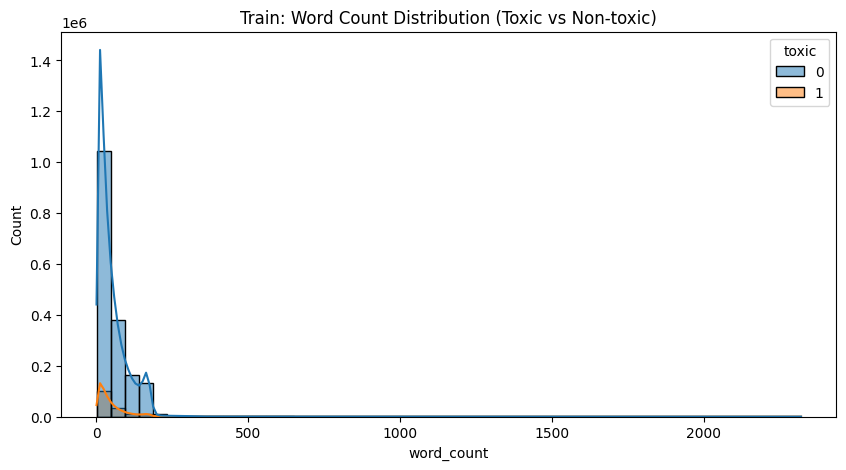

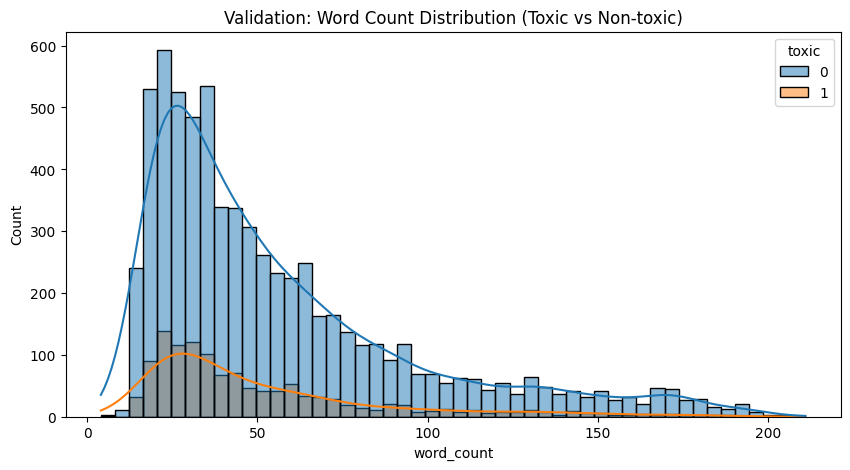

In [ ]:
# Basic Length features
print_section("Creating Text Length Features")

def add_length_features(df):
    df["char_length"] = df["comment_text"].astype(str).apply(len)
    df["word_count"] = df["comment_text"].astype(str).apply(lambda x: len(x.split()))
    return df

train_df = add_length_features(train_df)
dev_df = add_length_features(dev_df)
val_df = add_length_features(val_df)

# Length distribution (toxic vs non-toxic)
print_section("Length Distribution Analysis")

plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x="word_count", hue="toxic", bins=50, kde=True)
plt.title("Train: Word Count Distribution (Toxic vs Non-toxic)")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(data=val_df, x="word_count", hue="toxic", bins=50, kde=True)
plt.title("Validation: Word Count Distribution (Toxic vs Non-toxic)")
plt.show()

**Discovery**: The distribution is right-skewed with a heavy tail, and toxic comments are slightly left-shifted.

In [ ]:
# Average length comparison
print_section("Average Length Comparison")

def length_summary(df, name):
    return pd.DataFrame({
        "dataset": [name],
        "avg_word_toxic": [df[df.toxic==1]["word_count"].mean()],
        "avg_word_non_toxic": [df[df.toxic==0]["word_count"].mean()]
    })

summary = pd.concat([
    length_summary(train_df, "train"),
    length_summary(val_df, "validation")
])

print(summary)


Average Length Comparison
      dataset  avg_word_toxic  avg_word_non_toxic
0       train       48.670808           53.665679
0  validation       50.386179           56.100015


**Discovery**: Toxic comments are symetrically shorter.

In [ ]:
# Top frequent words (toxic vs non-toxic)
print_section("Top Frequent Words")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def get_top_words(df, label, n=20):
    texts = df[df["toxic"] == label]["comment_text"].apply(clean_text)
    words = " ".join(texts).split()
    counter = Counter(words)
    return counter.most_common(n)

top_non_toxic = get_top_words(train_df, 0)
top_toxic = get_top_words(train_df, 1)

print("\nTop Non-Toxic Words:")
print(top_non_toxic)

print("\nTop Toxic Words:")
print(top_toxic)


Top Frequent Words

Top Non-Toxic Words:
[('the', 4758529), ('to', 2673893), ('and', 2221004), ('of', 2058653), ('a', 1945843), ('is', 1525917), ('in', 1399020), ('that', 1323956), ('you', 1011245), ('i', 1010909), ('for', 958893), ('it', 948816), ('not', 738069), ('are', 724254), ('be', 659158), ('on', 644089), ('have', 625500), ('this', 621232), ('with', 578933), ('as', 560234)]

Top Toxic Words:
[('the', 327755), ('to', 195107), ('and', 189174), ('a', 175142), ('of', 150783), ('is', 133609), ('you', 132594), ('that', 95108), ('in', 93240), ('i', 80012), ('are', 73639), ('for', 68942), ('it', 66103), ('this', 53548), ('not', 50494), ('be', 46644), ('on', 46635), ('with', 46148), ('have', 45748), ('they', 45630)]


In [ ]:
# After eliminating stop words
stop_words = set(ENGLISH_STOP_WORDS)

def get_top_words_filtered(df, label, n=20):
    texts = df[df["toxic"] == label]["comment_text"].apply(clean_text)
    words = [w for w in " ".join(texts).split() if w not in stop_words]
    counter = Counter(words)
    return counter.most_common(n)

print("\nTop Toxic Words (Filtered):")
print(get_top_words_filtered(train_df, 1))

print("\nTop Non-Toxic Words (Filtered):")
print(get_top_words_filtered(train_df, 0))


Top Toxic Words (Filtered):
[('people', 28374), ('like', 28100), ('trump', 27941), ('just', 26522), ('dont', 21399), ('stupid', 15589), ('fuck', 13763), ('know', 13087), ('think', 12699), ('time', 11366), ('white', 10923), ('right', 10875), ('did', 9777), ('want', 9515), ('make', 9418), ('im', 9165), ('good', 9105), ('way', 8544), ('youre', 8358), ('really', 8300)]

Top Non-Toxic Words (Filtered):
[('people', 275809), ('just', 252676), ('like', 246477), ('dont', 216054), ('trump', 166742), ('time', 154058), ('think', 154037), ('know', 139714), ('good', 135358), ('did', 123718), ('make', 118173), ('right', 117240), ('years', 117110), ('article', 116117), ('way', 113785), ('need', 109665), ('does', 106032), ('want', 103806), ('im', 100747), ('government', 98060)]


After removing stopwords, a strong overlap in vocabulary between toxic and non-toxic comments remains. Words such as “people”, “like”, “just”, and “think” appear frequently in both classes。 This indicates most tokens are not discriminative.

However, toxic comments contain a small set of highly indicative words, such as “stupid” and “fuck”, which serve as strong signals of toxicity. These words are relatively less frequent but carry high predictive power.

In contrast, non-toxic comments do not exhibit equally strong distinguishing keywords. This suggests that classification relies more on the presence of explicit offensive language rather than distinct “non-toxic” patterns.


Train vs Validation Distribution
      dataset  positive_ratio
0       train        0.081777
1  validation        0.153769


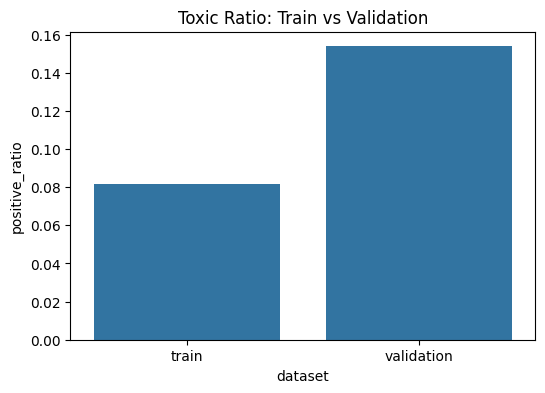

In [ ]:
# Compare Train vs Validation Distribution
print_section("Train vs Validation Distribution")

dist_df = pd.DataFrame({
    "dataset": ["train", "validation"],
    "positive_ratio": [
        train_df["toxic"].mean(),
        val_df["toxic"].mean()
    ]
})

print(dist_df)

plt.figure(figsize=(6,4))
sns.barplot(data=dist_df, x="dataset", y="positive_ratio")
plt.title("Toxic Ratio: Train vs Validation")
plt.show()

In [ ]:
# Sample Toxic Comments
print_section("Sample Toxic Comments")
print(train_df[train_df["toxic"]==1]["comment_text"].sample(3, random_state=42).tolist())

# Sample Non-toxic Comments
print_section("Sample Non-Toxic Comments")
print(train_df[train_df["toxic"]==0]["comment_text"].sample(3, random_state=42).tolist())


Sample Toxic Comments
['hello there is a special place in hell for your kind of faggotry. enjoy the ban.', "That you, in spite of the abundant information available, don't know or won't recognize that the number of uninsured drastically fell is unfortunate. Your GP's anecdotal story is sweet because that is not the position of the AMA. Lastly, that you are so self-absorbed to think that only someone who themselves got free insurance could see the benefit in eliminating pre-existing conditions and insuring 25 million more people, is pathetic.", "So, the republicans were voted in but failed to do what they promised so they fooled us once and it's shame on them because they didn't follow through. Okay, the next election the republicans were voted in and again didn't do what they were supposed to do. I would say they fooled us again, but it's our fault because we were stupid enough to trust and vote for them a second time, so now it is shame on us."]

Sample Non-Toxic Comments
['The "unde